In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/india_agriculture_seed_sales_data.csv')

In [6]:
#  Inventory Risk Score 
df['Inv_Risk_Score'] = (
    (df['Days_to_Sell_Inventory'] / df['Days_to_Sell_Inventory'].max()) * 0.4 +
    (1 - df['Farmer_Sentiment_Score'] / df['Farmer_Sentiment_Score'].max()) * 0.3 +
    (df['Competitor_Market_Share_%'] / 100) * 0.3
)
print('Mean inventory risk score:' ,df['Inv_Risk_Score'].mean().round(2))

Mean inventory risk score: 0.55


In [7]:
# Quota Analysis
df['Quota_Gap']   = df['Sales_Target'] - df['Actual_Units_Sold']
df['Quota_Gap_%'] = (df['Quota_Gap'] / df['Sales_Target'] * 100)

print('=' * 65)
print('INVENTORY & SUPPLY CHAIN ANALYSIS')
print('=' * 65)

print('\nInventory Risk by Region:')
print(df.groupby('Region')['Inv_Risk_Score'].mean().sort_values(ascending=False).round(3).to_string())

print('\nQuota Gap by Region (Avg % below target):')
print(df.groupby('Region')['Quota_Gap_%'].mean().sort_values(ascending=False).round(1).to_string())

print('\nCorrelation Matrix (Days_to_Sell vs drivers):')
corr_cols = ['Days_to_Sell_Inventory', 'Actual_Units_Sold', 'Farmer_Sentiment_Score',
             'Competitor_Market_Share_%', 'Warehouse_Quantity', 'Rainfall_mm',
             'Pest_Infestation_Index', 'Seed_Quality_Index_%']
print(df[corr_cols].corr()['Days_to_Sell_Inventory'].drop('Days_to_Sell_Inventory').sort_values().round(4).to_string())


INVENTORY & SUPPLY CHAIN ANALYSIS

Inventory Risk by Region:
Region
West       0.549
North      0.548
East       0.548
Central    0.548
South      0.546

Quota Gap by Region (Avg % below target):
Region
South     -2.4
Central   -3.5
North     -3.8
East      -5.2
West      -5.7

Correlation Matrix (Days_to_Sell vs drivers):
Farmer_Sentiment_Score      -0.0114
Seed_Quality_Index_%        -0.0022
Actual_Units_Sold           -0.0016
Competitor_Market_Share_%    0.0010
Pest_Infestation_Index       0.0054
Rainfall_mm                  0.0067
Warehouse_Quantity           0.0075


Inventory Turnover 

In [2]:
df['Inventory_Turnover'] = df['Actual_Units_Sold'] / df['Warehouse_Quantity']

inv_analysis = df.groupby(['Region','Vegetable_Type']).agg(
    Avg_Days_to_Sell=('Days_to_Sell_Inventory','mean'),
    Avg_Turnover=('Inventory_Turnover','mean'),
    Avg_Warehouse_Qty=('Warehouse_Quantity','mean'),
    Avg_Units_Sold=('Actual_Units_Sold','mean')
).round(2)

# Worst performing (highest days to sell)
worst_inv = inv_analysis['Avg_Days_to_Sell'].sort_values(ascending=False).head(10)
print("Worst Inventory Performers (Days to Sell):")
print(worst_inv)

Worst Inventory Performers (Days to Sell):
Region   Vegetable_Type
West     Okra              65.99
         Tomato            65.82
North    Tomato            65.80
West     Onion             65.66
         Carrot            65.56
North    Carrot            65.55
East     Okra              65.52
North    Onion             65.47
Central  Carrot            65.39
         Cauliflower       65.29
Name: Avg_Days_to_Sell, dtype: float64


Sales Target Achievement

In [3]:
df['Target_Achievement_%'] = (df['Actual_Units_Sold'] / df['Sales_Target'] * 100).round(2)

target = df.groupby(['Year','Region']).agg(
    Avg_Achievement=('Target_Achievement_%','mean'),
    Total_Sold=('Actual_Units_Sold','sum'),
    Total_Target=('Sales_Target','sum')
).round(2)
print("\nSales Target Achievement by Year & Region:")
print(target)


Sales Target Achievement by Year & Region:
              Avg_Achievement  Total_Sold  Total_Target
Year Region                                            
2021 Central           102.42      650239        699068
     East              104.24      604811        636766
     North             103.12      646833        683677
     South             100.00      594007        652834
     West              104.80      653532        682526
2022 Central           102.09      644820        688039
     East              104.49      625941        651974
     North             104.71      618148        652159
     South             103.63      657169        694921
     West              103.69      620211        657939
2023 Central           104.66      614688        651250
     East              107.20      625763        646038
     North             103.43      687483        731056
     South             105.38      658298        685180
     West              104.71      595910        621283
2024


Saved: inventory_supply_chain.png


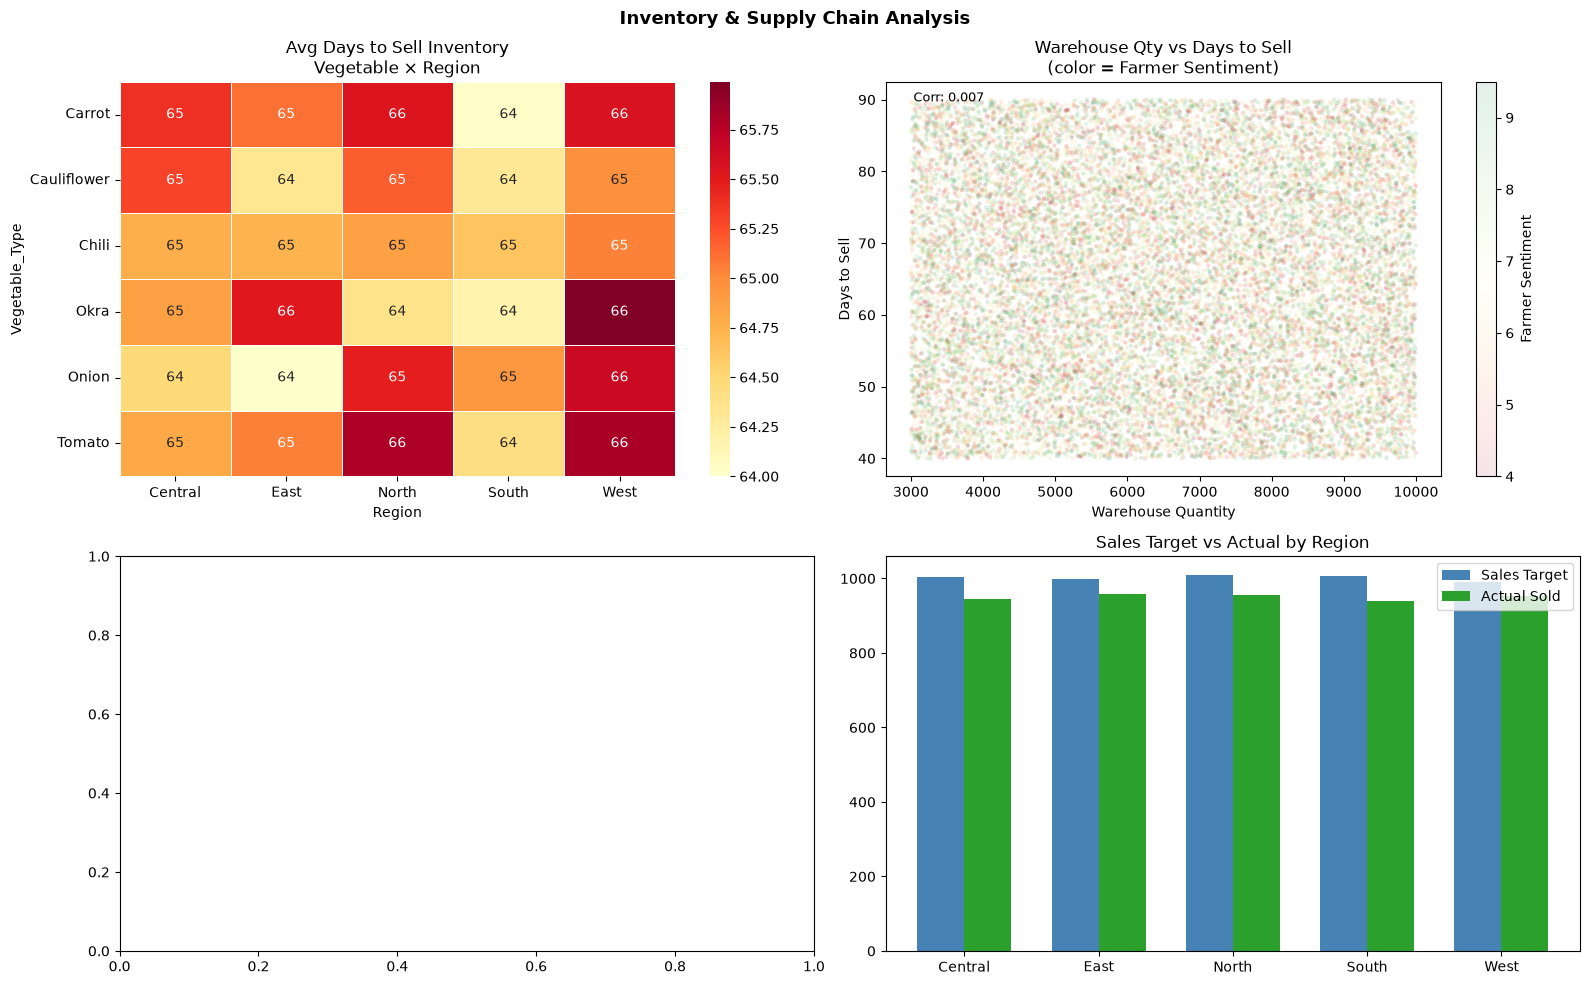

In [ ]:
# Inventory Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Days to sell heatmap by veg x region
inv_heatmap = df.pivot_table(values='Days_to_Sell_Inventory',
                              index='Vegetable_Type', columns='Region', aggfunc='mean')
sns.heatmap(inv_heatmap, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[0, 0], linewidths=0.5)
axes[0, 0].set_title('Avg Days to Sell Inventory\nVegetable × Region')

# Panel 2: Warehouse vs Days to Sell
sc = axes[0, 1].scatter(df['Warehouse_Quantity'], df['Days_to_Sell_Inventory'],
                         alpha=0.1, c=df['Farmer_Sentiment_Score'],
                         cmap='RdYlGn', s=5)
axes[0, 1].set_xlabel('Warehouse Quantity')
axes[0, 1].set_ylabel('Days to Sell')
axes[0, 1].set_title('Warehouse Qty vs Days to Sell\n(color = Farmer Sentiment)')
plt.colorbar(sc, ax=axes[0, 1], label='Farmer Sentiment')
corr = df['Warehouse_Quantity'].corr(df['Days_to_Sell_Inventory'])
axes[0, 1].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[0, 1].transAxes, fontsize=9)

# Panel 3: Quota vs Actual by Region
quota_reg = df.groupby('Region').agg(
    Avg_Target=('Sales_Target', 'mean'),
    Avg_Actual=('Actual_Units_Sold', 'mean')
).reset_index()
x = np.arange(len(quota_reg))
w = 0.35
axes[1, 1].bar(x - w / 2, quota_reg['Avg_Target'], w, label='Sales Target', color='steelblue')
axes[1, 1].bar(x + w / 2, quota_reg['Avg_Actual'], w, label='Actual Sold', color='#2ca02c')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(quota_reg['Region'])
axes[1, 1].set_title('Sales Target vs Actual by Region')
axes[1, 1].legend()

plt.suptitle('Inventory & Supply Chain Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/inventory_supply_chain.png', bbox_inches='tight')
print('\nSaved: inventory_supply_chain.png')




Saved: quota_rejection_analysis.png


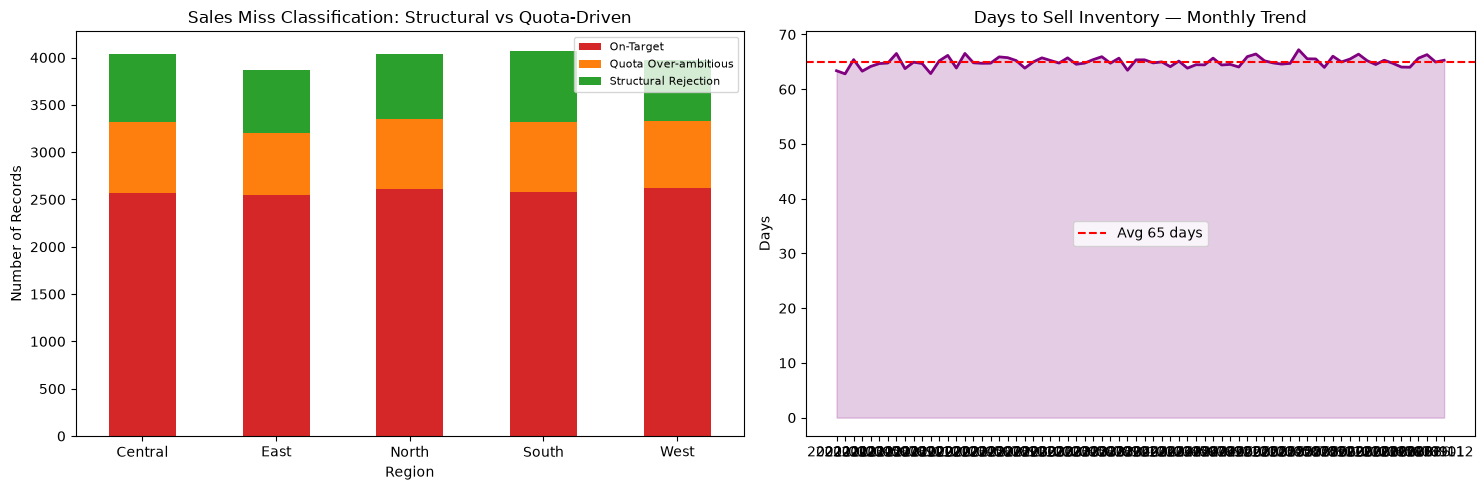

In [10]:
# Quota Analysis — Over-quota vs Structural Rejection ────────────────
# Categorise rows: high quota gap + low sentiment = structural; else = quota-driven
df['Rejection_Type'] = 'On-Target'
df.loc[(df['Quota_Gap_%'] > 20) & (df['Farmer_Sentiment_Score'] < df['Farmer_Sentiment_Score'].median()),
       'Rejection_Type'] = 'Structural Rejection'
df.loc[(df['Quota_Gap_%'] > 20) & (df['Farmer_Sentiment_Score'] >= df['Farmer_Sentiment_Score'].median()),
       'Rejection_Type'] = 'Quota Over-ambitious'

rej_region = df.groupby(['Region', 'Rejection_Type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rej_region.plot(kind='bar', ax=axes[0], stacked=True,
                color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Sales Miss Classification: Structural vs Quota-Driven')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Number of Records')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Days to sell trend
monthly_inv = df.groupby('Date')['Days_to_Sell_Inventory'].mean()
axes[1].plot(monthly_inv.index, monthly_inv.values, color='purple', lw=2)
axes[1].fill_between(monthly_inv.index, monthly_inv.values, alpha=0.2, color='purple')
axes[1].axhline(monthly_inv.mean(), color='red', lw=1.5, linestyle='--',
                label=f'Avg {monthly_inv.mean():.0f} days')
axes[1].set_title('Days to Sell Inventory — Monthly Trend')
axes[1].set_ylabel('Days')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/quota_rejection_analysis.png', bbox_inches='tight')
print('Saved: quota_rejection_analysis.png')
